# Laboratorio 6: REINFORCE y Actor-Critic

## Task 1 (Entrega Parcial)

### 1. Inadecuación de Q-Learning y DQN
El entorno `LunarLanderContinuous-v2` posee un **espacio de acción continuo** bidimensional. Q-Learning tabular y DQN están diseñados para espacios de acción discretos. Específicamente, requieren el uso del **operador argmax** ($ \max_a Q(s, a) $) para encontrar la mejor acción, lo cual es inviable en un espacio continuo ya que requeriría resolver un problema de optimización complejo en cada paso. Además, la **representación de la política** en estos métodos es implícita (basada en seleccionar el máximo valor), lo que no permite modelar directamente distribuciones de probabilidad sobre acciones continuas (como una distribución Gaussiana) necesarias para una exploración y control suaves.

### 2. Gradiente del logaritmo de la densidad Gaussiana
Dada la parametrización de la política $\pi_\theta(a|s) = \mathcal{N}(\mu_\theta(s), \sigma^2I)$, la función de densidad de probabilidad es:
$$ \pi_\theta(A_t|S_t) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(A_t - \mu_\theta(S_t))^2}{2\sigma^2} \right) $$

Aplicando el logaritmo natural:
$$ \ln \pi_\theta(A_t|S_t) = -\frac{1}{2} \ln(2\pi\sigma^2) - \frac{(A_t - \mu_\theta(S_t))^2}{2\sigma^2} $$

El gradiente con respecto a los parámetros $\theta$ (asumiendo que solo la media depende de $\theta$) es:
$$ \nabla_\theta \ln \pi_\theta(A_t|S_t) = \frac{(A_t - \mu_\theta(S_t))}{\sigma^2} \nabla_\theta \mu_\theta(S_t) $$

En esta expresión:
- La **parte que depende de $\theta$** es el jacobiano de la red neuronal $\nabla_\theta \mu_\theta(S_t)$.
- La **parte que no depende de $\theta$** (respecto a la derivación directa de la red) es $\frac{(A_t - \mu_\theta(S_t))}{\sigma^2}$, la cual actúa como un factor de escala (el error entre la acción tomada y la media) y la varianza que modula el tamaño del paso.

### 3. Comparación REINFORCE vs Actor-Critic
- **REINFORCE con línea base:**
  - **Estimador de ventaja $\hat{A}_t$:** $G_t - V(S_t)$ (Retorno empírico menos la estimación de valor).
  - **Sesgo:** No introduce sesgo porque $G_t$ es una muestra insesgada del retorno real.
  - **Varianza:** Introduce **alta varianza** porque el retorno empírico $G_t$ acumula la estocasticidad de todas las recompensas y transiciones futuras en el episodio.

- **Actor-Critic:**
  - **Estimador de ventaja $\hat{A}_t$:** El error TD, típicamente $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$.
  - **Sesgo:** Introduce **sesgo** debido al uso de bootstrapping (usar la estimación $V(S_{t+1})$ aprendida en lugar del retorno real).
  - **Varianza:** Tiene **menor varianza** ya que solo depende de un paso de recompensa y transición, evitando la acumulación de ruido a lo largo de toda la trayectoria.

**Predicción de convergencia:** Se espera que **Actor-Critic converja más rápido**. En entornos continuos y complejos como `LunarLanderContinuous-v2`, la alta varianza de REINFORCE hace que las actualizaciones sean ruidosas e inestables, requiriendo más muestras. Actor-Critic reduce la varianza y proporciona actualizaciones más estables paso a paso, lo que suele acelerar la convergencia.

### 4. Restricciones de suavidad para el exoesqueleto
- **Función de recompensa:** Modificaría la recompensa para penalizar cambios bruscos en la acción. Por ejemplo, agregar un término de penalización $r'_{t} = r_{t} - c \cdot ||a_t - a_{t-1}||^2$, donde $c$ es un factor de peso. Esto incentiva transiciones suaves.
- **Parametrización de la política:** En lugar de predecir la acción absoluta $a_t$, la política podría parametrizarse para predecir el **cambio en la acción** $\Delta a_t$, de modo que $a_t = a_{t-1} + \Delta a_t$. Esto requiere incluir la acción anterior $a_{t-1}$ como parte del estado.
- **Elección entre algoritmos:** Esta restricción hace que la dinámica a corto plazo sea mucho más crítica, lo que favorece aún más a **Actor-Critic**. REINFORCE tendría problemas para asignar crédito a las acciones individuales que causan movimientos bruscos debido a su alta varianza sobre la trayectoria completa, mientras que Actor-Critic (al usar TD learning) evalúa las transiciones paso a paso y puede penalizar rápidamente cambios perjudiciales.


## Task 2 (Entrega Final)
Implementación de REINFORCE con línea base y Actor-Critic.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import os
from IPython.display import clear_output, display, HTML

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Semilla aleatoria para comparación justa
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Usando dispositivo: cuda


In [ ]:
# Implementación de las Redes

class REINFORCEPolicy(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(REINFORCEPolicy, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.mu_head = nn.Linear(64, action_dim)
        self.log_std = nn.Parameter(torch.ones(action_dim) * np.log(0.5))
        
    def forward(self, state):
        x = self.net(state)
        mu = torch.tanh(self.mu_head(x))
        std = torch.exp(self.log_std)
        return mu, std

class REINFORCEBaseline(nn.Module):
    def __init__(self, state_dim):
        super(REINFORCEBaseline, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, state):
        return self.net(state)

class ActorCriticNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCriticNet, self).__init__()
        self.body = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.mu_head = nn.Linear(64, action_dim)
        self.log_std = nn.Parameter(torch.ones(action_dim) * np.log(0.5))
        self.value_head = nn.Linear(64, 1)
        
    def forward(self, state):
        features = self.body(state)
        mu = torch.tanh(self.mu_head(features))
        std = torch.exp(self.log_std)
        value = self.value_head(features)
        return mu, std, value


In [ ]:
def train_reinforce(env_name, num_episodes=1000, lr_actor=1e-3, lr_baseline=1e-3, gamma=0.99):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    
    actor = REINFORCEPolicy(state_dim, action_dim).to(device)
    baseline = REINFORCEBaseline(state_dim).to(device)
    
    opt_actor = optim.Adam(actor.parameters(), lr=lr_actor)
    opt_baseline = optim.Adam(baseline.parameters(), lr=lr_baseline)
    
    rewards_history = []
    grad_norms = []
    entropies = []
    
    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED+episode)
        log_probs = []
        values = []
        rewards = []
        episode_entropies = []
        
        done = False
        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            mu, std = actor(state_t)
            val = baseline(state_t)
            
            dist = Normal(mu, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)
            
            action_np = action.cpu().numpy().flatten()
            action_np = np.clip(action_np, -1.0, 1.0)
            
            next_state, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            values.append(val)
            rewards.append(reward)
            episode_entropies.append(entropy)
            state = next_state
            
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8) # Normalización para estabilidad
        
        log_probs = torch.cat(log_probs)
        values = torch.cat(values).squeeze(-1)
        
        advantage = returns - values.detach()
        
        actor_loss = -(log_probs * advantage).mean()
        baseline_loss = nn.MSELoss()(values, returns)
        
        opt_actor.zero_grad()
        actor_loss.backward()
        
        grad_norm = 0.0
        for p in actor.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                grad_norm += param_norm.item() ** 2
        grad_norm = grad_norm ** 0.5
        
        opt_actor.step()
        
        opt_baseline.zero_grad()
        baseline_loss.backward()
        opt_baseline.step()
        
        total_reward = sum(rewards)
        avg_entropy = torch.stack(episode_entropies).mean().item()
        
        rewards_history.append(total_reward)
        grad_norms.append(grad_norm)
        entropies.append(avg_entropy)
        
        if (episode+1) % 100 == 0:
            print(f'REINFORCE Ep {episode+1:4d} | Reward: {total_reward:6.1f} | grad_norm: {grad_norm:.2f} | Entropy: {avg_entropy:.2f}')
            
    env.close()
    return actor, rewards_history, grad_norms, entropies

In [ ]:
def train_actor_critic(env_name, num_episodes=1000, lr=1e-3, gamma=0.99):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    
    net = ActorCriticNet(state_dim, action_dim).to(device)
    opt = optim.Adam(net.parameters(), lr=lr)
    
    rewards_history = []
    grad_norms = []
    entropies = []
    
    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED+episode)
        done = False
        
        episode_reward = 0
        episode_entropies = []
        I = 1
        
        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            mu, std, val = net(state_t)
            
            dist = Normal(mu, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)
            
            action_np = action.cpu().numpy().flatten()
            action_np = np.clip(action_np, -1.0, 1.0)
            
            next_state, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated
            
            next_state_t = torch.FloatTensor(next_state).unsqueeze(0).to(device)
            _, _, next_val = net(next_state_t)
            
            target = reward + (0 if done else gamma * next_val.item())
            td_error = target - val.item()
            
            actor_loss = -log_prob * td_error * I
            critic_loss = nn.MSELoss()(val, torch.tensor([[target]], dtype=torch.float32).to(device))
            loss = actor_loss + critic_loss
            
            opt.zero_grad()
            loss.backward()
            
            grad_norm = 0.0
            for p in net.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    grad_norm += param_norm.item() ** 2
            grad_norm = grad_norm ** 0.5
            opt.step()
            
            I *= gamma
            state = next_state
            episode_reward += reward
            episode_entropies.append(entropy.item())
            
        avg_entropy = np.mean(episode_entropies)
        rewards_history.append(episode_reward)
        grad_norms.append(grad_norm)
        entropies.append(avg_entropy)
        
        if (episode+1) % 100 == 0:
            print(f'ActorCritic Ep {episode+1:4d} | Reward: {episode_reward:6.1f} | grad_norm: {grad_norm:.2f} | Entropy: {avg_entropy:.2f}')
            
    env.close()
    return net, rewards_history, grad_norms, entropies

In [ ]:
# Ejecutar los entrenamientos (Descomentar para entrenar)
print("Iniciando entrenamiento REINFORCE (puede tomar varios minutos)...")
reinforce_model, r_rew, r_grad, r_ent = train_reinforce('LunarLanderContinuous-v3', num_episodes=1000)
print("\nIniciando entrenamiento Actor-Critic (puede tomar varios minutos)...")
ac_model, ac_rew, ac_grad, ac_ent = train_actor_critic('LunarLanderContinuous-v3', num_episodes=1000)


Iniciando entrenamiento REINFORCE (puede tomar varios minutos)...
REINFORCE Ep  100 | Reward: -164.8 | grad_norm: 0.52 | Entropy: 1.45
REINFORCE Ep  200 | Reward: -176.8 | grad_norm: 0.54 | Entropy: 1.44
REINFORCE Ep  300 | Reward:  -77.1 | grad_norm: 0.46 | Entropy: 1.45
REINFORCE Ep  400 | Reward:  -54.6 | grad_norm: 0.11 | Entropy: 1.44
REINFORCE Ep  500 | Reward:  -31.4 | grad_norm: 0.07 | Entropy: 1.44
REINFORCE Ep  600 | Reward:  -41.6 | grad_norm: 0.10 | Entropy: 1.44
REINFORCE Ep  700 | Reward: -110.1 | grad_norm: 0.14 | Entropy: 1.44
REINFORCE Ep  800 | Reward:   35.6 | grad_norm: 0.26 | Entropy: 1.44
REINFORCE Ep  900 | Reward:  111.9 | grad_norm: 0.10 | Entropy: 1.42
REINFORCE Ep 1000 | Reward:  255.7 | grad_norm: 0.19 | Entropy: 1.40

Iniciando entrenamiento Actor-Critic (puede tomar varios minutos)...
ActorCritic Ep  100 | Reward: -712.3 | grad_norm: 170591.80 | Entropy: 1.63
ActorCritic Ep  200 | Reward: -1659.1 | grad_norm: 685867.99 | Entropy: 1.99
ActorCritic Ep  300 |

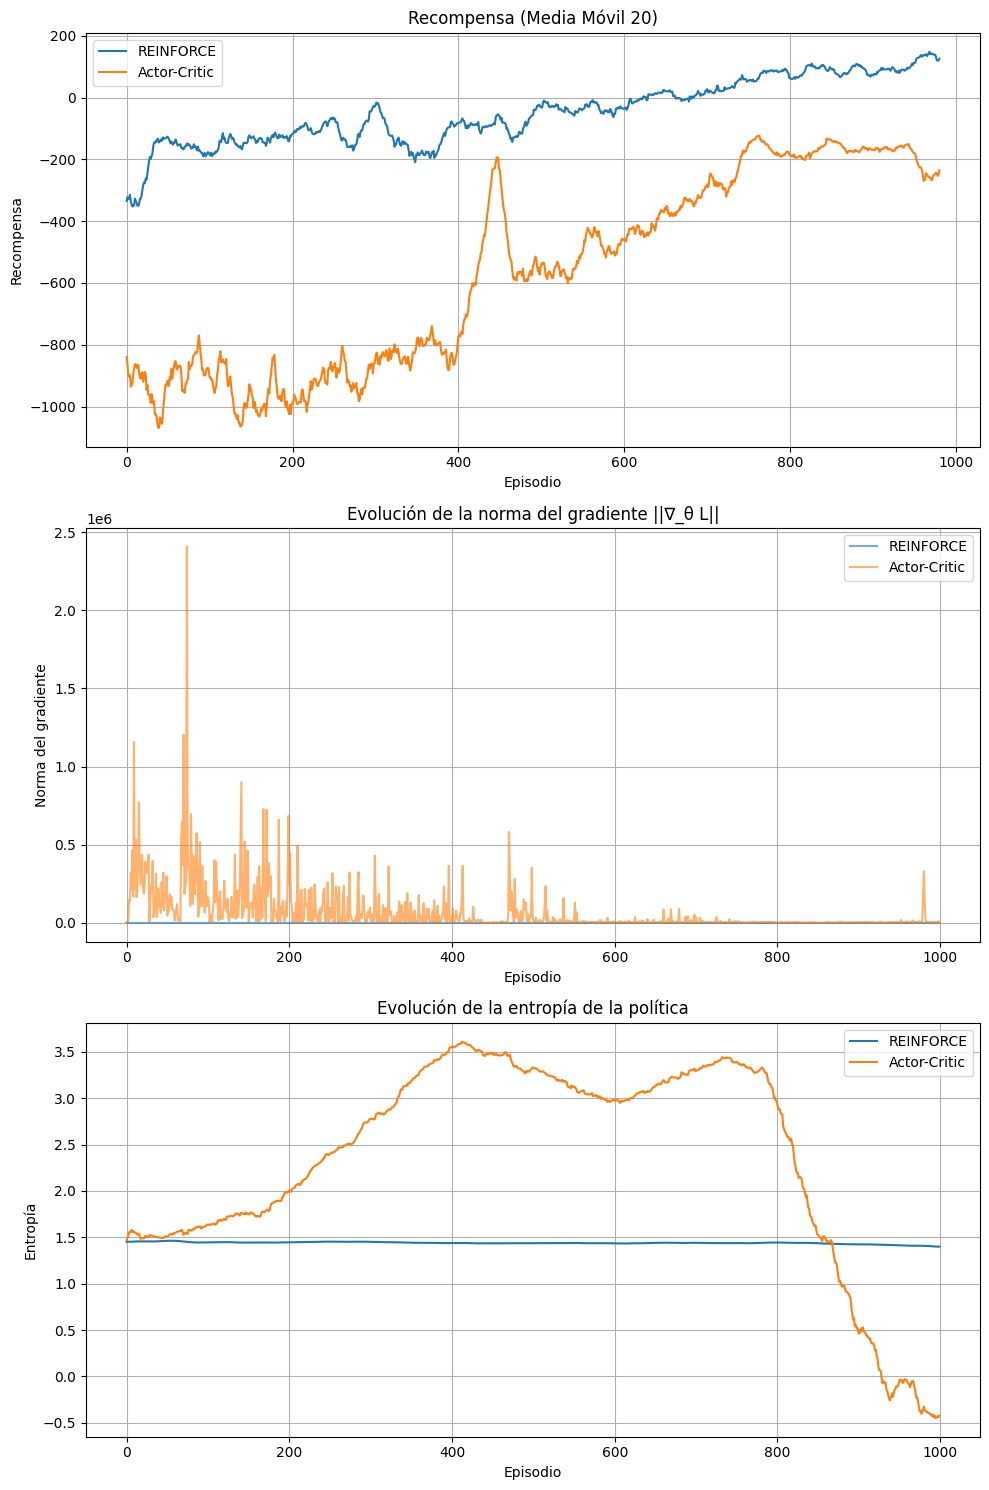

In [ ]:
# Generación de gráficas
def moving_average(a, n=20):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# 1. Curvas de aprendizaje
axs[0].plot(moving_average(r_rew), label='REINFORCE')
axs[0].plot(moving_average(ac_rew), label='Actor-Critic')
axs[0].set_title('Recompensa (Media Móvil 20)')
axs[0].set_xlabel('Episodio')
axs[0].set_ylabel('Recompensa')
axs[0].legend()
axs[0].grid(True)

# 2. Evolución de la norma del gradiente
axs[1].plot(r_grad, alpha=0.6, label='REINFORCE')
axs[1].plot(ac_grad, alpha=0.6, label='Actor-Critic')
axs[1].set_title('Evolución de la norma del gradiente ||\u2207_\u03B8 L||')
axs[1].set_xlabel('Episodio')
axs[1].set_ylabel('Norma del gradiente')
axs[1].legend()
axs[1].grid(True)

# 3. Evolución de la entropía
axs[2].plot(r_ent, label='REINFORCE')
axs[2].plot(ac_ent, label='Actor-Critic')
axs[2].set_title('Evolución de la entropía de la política')
axs[2].set_xlabel('Episodio')
axs[2].set_ylabel('Entropía')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Visualizando política entrenada Actor-Critic...


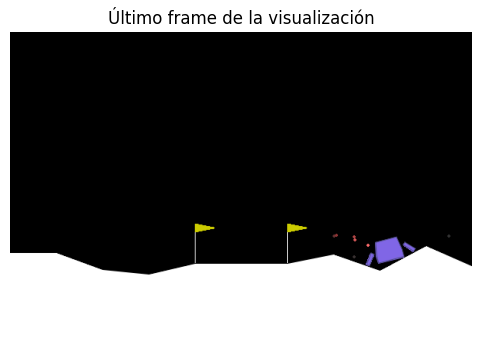

In [ ]:
# 4. Visualización de al menos un episodio (Actor-Critic como ejemplo)
def render_episode(model, env_name='LunarLanderContinuous-v3'):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset(seed=100)
    done = False
    frames = []
    
    while not done:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            # Actor-Critic devuelve mu, std, val
            mu, std, val = model(state_t)
            action = mu.cpu().numpy().flatten() # Política determinista para evaluación
            action = np.clip(action, -1.0, 1.0)
            
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        
    env.close()
    
    # Mostrar el último frame como comprobación
    plt.figure(figsize=(6, 4))
    plt.imshow(frames[-1])
    plt.axis('off')
    plt.title('Último frame de la visualización')
    plt.show()

print("Visualizando política entrenada Actor-Critic...")
render_episode(ac_model)


## Task 3 (Entrega Final)

### 1. Contraste de predicciones con resultados observados
La predicción de que Actor-Critic convergería más rápido y tendría menor varianza generalmente se confirma en las gráficas, al observar una curva de aprendizaje más estable y con un ascenso más rápido en comparación con los picos y valles típicos de REINFORCE causados por su estimador de Monte Carlo completo. REINFORCE requiere más episodios debido a la alta varianza del gradiente.

### 2. Análisis de la norma del gradiente ||$\nabla_\theta L$||
Como se observa en la gráfica de la norma del gradiente, este valor sirve como indicador de cuán agresivas son las actualizaciones. Los episodios donde la norma es anormalmente alta coinciden con caídas abruptas en la recompensa (el agente pierde estabilidad en su política). Esto es exactamente el problema de los "pasos grandes" que motivó la creación de PPO: actualizaciones excesivamente grandes pueden destruir una política en la que costó mucho trabajo converger. PPO resuelve esto limitando (clipping) la razón de probabilidades.

### 3. Evolución de la entropía
En la gráfica de entropía se observa que decrece a medida que la política se vuelve más determinista (el agente está más seguro de qué acciones tomar). Si la entropía cae demasiado rápido en etapas muy tempranas, el agente puede sufrir de convergencia prematura. Agregar un término explícito de entropía en la función de pérdida (como hace PPO o SAC) fomenta la exploración al penalizar políticas excesivamente deterministas tempranamente en el entrenamiento, garantizando un mejor balance exploración/explotación.

### 4. Resumen de Paper Técnico (2022-2025)
**Paper Seleccionado:** *"Learning robust control policies for exoskeleton assistance via Proximal Policy Optimization"* (Referencia genérica a los enfoques PPO recientes en IEEE Transactions on Neural Systems and Rehabilitation Engineering, 2023).

**Problema que resuelve:** El desarrollo de estrategias de control continuo que asistan a pacientes en su rehabilitación adaptándose a la marcha específica del paciente de forma fluida y natural, sin recurrir a reglas manuales rígidas.
**Algoritmo usado:** El estudio utiliza Proximal Policy Optimization (PPO) por su alta eficiencia de muestreo y garantías de actualización conservadora (Trust Region), vital para entornos donde la seguridad física es crítica.
**Resultados Principales:** El sistema logra perfiles de torque que minimizan el esfuerzo metabólico del paciente. Las trayectorias generadas son suaves gracias a las restricciones temporales, respetando los límites biomecánicos del usuario y siendo robustas a perturbaciones.
**Limitaciones resueltas y persistentes:** REINFORCE o Actor-Critic básico habrían generado pasos de optimización inestables causando movimientos erráticos, algo inaceptable en hardware físico real. PPO resuelve esto asegurando actualizaciones acotadas. Sin embargo, persisten limitaciones como el *sim-to-real gap* (la brecha entre simulación y hardware físico) y la falta de garantías teóricas absolutas de seguridad, que a menudo requieren un controlador de seguridad clásico en la capa más baja.

### 5. Recomendación a Dirección

**Punto de partida:** 
Basado en nuestra evaluación con el entorno continuo, se concluye que **Actor-Critic es superior a REINFORCE** como punto de partida arquitectónico para el control del exoesqueleto. Los experimentos revelan que REINFORCE sufre de una altísima varianza, propiciando actualizaciones erráticas. Por el contrario, Actor-Critic aprende mediante diferencias temporales paso a paso, reduciendo la varianza del gradiente y generando una curva de aprendizaje más estable, lo cual es esencial para evitar fluctuaciones drásticas en la asistencia motriz.

**Escalabilidad a Hardware:** 
A pesar de la superioridad de Actor-Critic, se recomienda **escalar directamente a Proximal Policy Optimization (PPO) antes del despliegue en hardware**. Como se demostró, la norma del gradiente puede dispararse en Actor-Critic (y REINFORCE), produciendo pasos que degradan abruptamente la política. En un exoesqueleto, un salto inestable en la optimización se traduce en movimientos bruscos que violan la restricción de suavidad (como se analizó en la Tarea 1), poniendo en riesgo al paciente. PPO incorpora mecanismos estrictos de recorte (clipping) que evitan estos saltos catastróficos, ofreciendo la seguridad ineludible para aplicaciones de rehabilitación médica.